# 5. Regresión lineal múltiple

La Regresión Lineal Múltiple es una extensión de la Regresión Lineal Simple ya que utiliza más de una variable predictora para predecir la variable de respuesta. Es un algoritmo de regresión importante que modela la relación lineal entre una única variable continua dependiente y más de una variable independiente. Utiliza dos o más variables independientes para predecir una variable dependiente ajustando la mejor relación lineal.

Tiene dos o más variables independientes $X$ y una variable dependiente $Y$, donde $Y$ es el valor a ser predicho. Por lo tanto, es un enfoque para predecir una respuesta cuantitativa utilizando múltiples características.

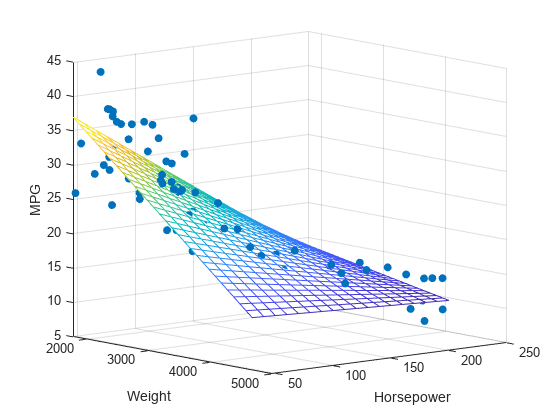

## 5.1 Estimación de los Coeficientes de Regresión

- **Modelo de Regresión Lineal Múltiple**: El modelo extiende el modelo de regresión lineal simple a situaciones donde hay más de un predictor.

  $$ Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_p X_p + \epsilon $$

  Donde:
  - $ Y $ es la respuesta.
  - $ X_1, X_2, ..., X_p $ son los predictores.
  - $ \beta_0, \beta_1, ..., \beta_p $ son los coeficientes desconocidos que representan el efecto promedio en $ Y $ de un incremento de una unidad en $ X_j $, manteniendo todos los otros predictores fijos.
  - $ \epsilon $ es el error.

- **Estimación de los Coeficientes**: Los coeficientes se estiman utilizando el mismo principio del método de mínimos cuadrados que en la regresión lineal simple. Se busca minimizar la suma de los cuadrados residuales (RSS).

  $$ RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2 $$
  
  Donde $ \hat{y}_i $ es la predicción que el modelo de regresión múltiple da para la i-ésima observación.

- **Interpretación de los Coeficientes**: En el contexto de un modelo de regresión múltiple, la interpretación de un coeficiente asociado a un predictor es el cambio promedio en la respuesta por cada incremento de una unidad en ese predictor, manteniendo todos los otros predictores constantes.

- **Fórmula Matricial para los Coeficientes**: La fórmula matricial proporciona una vista unificada de cómo se calculan los coeficientes. El libro presenta la fórmula para calcular los coeficientes en términos matriciales usando álgebra lineal.

## 5.2 Algunas preguntas que estaríamos interesados en responder

Cuando realizamos una regresión lineal múltiple, generalmente estamos interesados en responder algunas preguntas importantes.

1. ¿Es al menos uno de los predictores $X_1$, $X_2$,..., $X_p$ útil para predecir la respuesta?
2. ¿Todos los predictores ayudan a explicar $Y$, o solo un subconjunto de los predictores es útil?
3. ¿Qué tan bien se ajusta el modelo a los datos?
4. Dado un conjunto de valores predictores, ¿qué valor de respuesta deberíamos predecir y cuán preciso es nuestra predicción?

Ahora abordamos cada una de estas preguntas por turno.


### 1 ¿Hay relación lineal directa entre los predictores y la variable respuesta?

Para determinar la relación entre la variable respuesta y los predictores en la regresión múltiple, probamos:

$$ H_0: \beta_1 = \beta_2 = \ldots = \beta_p = 0 $$

contra la alternativa:

$$ H_a: \text{al menos un } \beta_j \text{ no es cero} $$

Usamos la **estadística F** para probar esta hipótesis:

$$ F = \frac{(TSS - RSS)}{p} \times \frac{1}{RSS/(n - p - 1)} $$

donde:
- $ TSS = \sum(y_i - \bar{y})^2 $
- $ RSS = \sum(y_i - \hat{y}_i)^2 $

Si no hay relación entre la respuesta y los predictores, se espera que F esté cerca de 1. De lo contrario, se espera que sea mayor que 1.

### 2. Selección de Variables
Elegir qué predictores están asociados con la respuesta se llama **selección de variables**. Hay tres enfoques clásicos para esto:

1. **Selección hacia adelante (Forward Selection)**:
    - Comienza con el modelo nulo (sin predictores).
    - Ajusta $ p $ regresiones lineales simples y añade la variable que da el menor RSS.
    - Continúa añadiendo la variable que mejora más el modelo hasta que se cumpla una regla de parada.

2. **Selección hacia atrás (Backward Selection)**:
    - Comienza con todas las variables en el modelo.
    - Elimina la variable con el valor p más grande (menos estadísticamente significativo).
    - Vuelve a ajustar el modelo y elimina nuevamente la variable con el valor p más grande.
    - Continúa hasta que se cumpla una regla de parada (por ejemplo, todas las variables restantes tienen un valor p por debajo de un umbral).

3. **Selección mixta (Mixed Selection)**:
    - Combina la selección hacia adelante y hacia atrás.
    - Comienza sin ninguna variable y añade la que proporcione el mejor ajuste, como en la selección hacia adelante.
    - Sin embargo, si el valor p de una variable supera un umbral a medida que se añaden otras, elimina esa variable.

> **Nota**: La selección hacia atrás no se puede usar si $ p > n $. La selección hacia adelante, siendo un enfoque ávido, podría incluir variables redundantes al principio. La selección mixta puede remediar esto.

#### Calidad del Modelo
Para determinar cuál modelo es el mejor entre los posibles 2^p modelos, podemos usar varias estadísticas, incluyendo:
- Cp de Mallow
- Criterio de Información de Akaike (AIC)
- Criterio de Información Bayesiano (BIC)
- $ R^2 $ ajustado

También se puede ayudar a identificar el mejor modelo trazando salidas del modelo, como residuos.

### 3. Ajuste del modelo

#### RSE y $ R^2 $

- **RSE** y **$ R^2 $** son dos medidas comunes para evaluar la calidad de ajuste de un modelo.
- En regresión lineal simple, $ R^2 $ es el cuadrado de la correlación entre la respuesta y la variable. En regresión lineal múltiple, es el cuadrado de la correlación entre la respuesta y el modelo lineal ajustado.

#### Observaciones sobre $ R^2 $

- Un valor de $ R^2 $ cercano a 1 indica que el modelo explica gran parte de la varianza de la respuesta.
- $ R^2 $ siempre aumentará al añadir más variables al modelo, incluso si estas variables están débilmente asociadas con la respuesta. Esto puede llevar a un sobreajuste del modelo.

### Predicciones

#### Incertidumbres en la Predicción con Regresión Múltiple

Al ajustar un modelo de regresión múltiple, es posible predecir la respuesta **Y** basándose en un conjunto de valores para los predictores **X1, X2,...,Xp**. Sin embargo, existen tres tipos de incertidumbres asociadas a esta predicción:

1. **Estimación de los Coeficientes**:
   - Los coeficientes estimados $ \hat\beta_0, \hat\beta_1,..., \hat\beta_p $ son aproximaciones de $ \beta_0, \beta_1,..., \beta_p $.
   - La inexactitud en la estimación de los coeficientes está relacionada con el error reducible.
   - Se pueden calcular intervalos de confianza para determinar cuán cerca estará $ \hat Y $ de $ f(X) $.

2. **Modelo Lineal como Aproximación**:
   - Asumir un modelo lineal para $ f(X) $ es casi siempre una aproximación de la realidad, lo que introduce un error potencialmente reducible llamado sesgo del modelo.
   - Sin embargo, se suele ignorar esta discrepancia y operar como si el modelo lineal fuera correcto.

3. **Error Irreducible**:
   - Incluso si conociéramos $ f(X) $ (los verdaderos valores de los coeficientes), no se puede predecir la respuesta perfectamente debido al error aleatorio en el modelo.
   - Se utiliza el término "error irreducible" para describir este fenómeno.
   - Se utilizan intervalos de predicción para cuantificar cuánto variará **Y** de $ \hat Y $. Estos intervalos de predicción siempre son más amplios que los intervalos de confianza porque incorporan tanto el error en la estimación de $ f(X) $ como la incertidumbre sobre cuánto variará un punto individual del plano de regresión de la población.

**Intervalos de Confianza vs Intervalos de Predicción**:
- Los intervalos de confianza cuantifican la incertidumbre en torno al valor medio de la respuesta.
- Los intervalos de predicción cuantifican la incertidumbre en torno a una respuesta individual.
- Los intervalos de predicción suelen ser más amplios debido a la mayor incertidumbre asociada a predecir una respuesta individual en comparación con predecir un promedio.

#### EJEMPLO

In [ ]:
#Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Conecting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ruta archivo csv
ruta_archivo = "/content/drive/MyDrive/notebooks maestria ECI/Company_data.csv"

# Leer el archivo CSV en un DataFrame de pandas
dataset = pd.read_csv(ruta_archivo)
dataset.sample(10)

,TV,Radio,Newspaper,Sales
169,284.3,10.6,6.4,20.0
64,131.1,42.8,28.9,16.0
148,38.0,40.3,11.9,10.9
27,240.1,16.7,22.9,20.9
147,243.2,49.0,44.3,25.4
113,209.6,20.6,10.7,20.9
80,76.4,26.7,22.3,11.8
133,219.8,33.5,45.1,19.6
176,248.4,30.2,20.3,20.2
139,184.9,43.9,1.7,20.7


In [ ]:
#Setting the value for X and Y
x = dataset[['TV', 'Radio', 'Newspaper']]
y = dataset['Sales']

In [ ]:
#Splitting the dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 100)

In [ ]:
#Fitting the Multiple Linear Regression model
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(x_train, y_train)

LinearRegression()

In [ ]:
#Intercept and Coefficient
print("Intercept: ", mlr.intercept_)
print("Coefficients:")
list(zip(x, mlr.coef_))

Intercept:  4.334595861728431
Coefficients:


[('TV', 0.053829108667250075),
 ('Radio', 0.11001224388558054),
 ('Newspaper', 0.0062899501461303325)]

Ecuación de regresion:

$Sales = 4.3345+ (0.0538 * TV) + (0.1100* Radio) + (0.0062 * Newspaper) + \epsilon$

In [ ]:
# Adding a constant to get an intercept
import statsmodels.api as sm
X_train_sm = sm.add_constant(x_train)
lr = sm.OLS(y_train, X_train_sm).fit()
# Printing the parameters
lr.params

const        4.334596
TV           0.053829
Radio        0.110012
Newspaper    0.006290
dtype: float64

In [ ]:
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     461.2
Date:                Sat, 16 Sep 2023   Prob (F-statistic):           4.73e-71
Time:                        09:05:46   Log-Likelihood:                -270.60
No. Observations:                 140   AIC:                             549.2
Df Residuals:                     136   BIC:                             561.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3346      0.357     12.139      0.000       3.628       5.041
TV             0.0538      0.002     34.539      0.000       0.051       0.057
Radio          0.1100      0.010     10.609      0.000       0.090       0.131
Newspaper      0.0063      0.007      0.902      0.369      -0.008       0.020
==============================================================================
Omnibus:                       18.669   Durbin-Watson:                   2.069
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               31.404
Skew:                          -0.643   Prob(JB):                     1.52e-07
Kurtosis:                       4.932   Cond. No.                         443.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### FORWARD STEPWISE

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf  # Importamos este módulo adicional
import numpy as np
import pandas as pd

# Generar datos de ejemplo
np.random.seed(0)
X = np.random.rand(100, 5)  # Cinco predictores
y = X[:, 0] + 2*X[:, 2] + np.random.randn(100)  # Respuesta

# Convertir a DataFrame para mejor manejo
df = pd.DataFrame(X, columns=[f'X{i}' for i in range(1, 6)])

def forward_selection(data, response):
    remaining = set(data.columns)
    remaining.remove(response)  # Eliminamos la columna de respuesta de las candidatas
    selected = []
    current_score, best_new_score = float('inf'), float('inf')

    while remaining and current_score == best_new_score:
        scores_with_candidates = []
        for candidate in remaining:
            formula = "{} ~ {}".format(response, ' + '.join(selected + [candidate]))
            score = smf.ols(formula, data).fit().aic  # Cambiamos sm.ols por smf.ols
            scores_with_candidates.append((score, candidate))
        scores_with_candidates.sort(reverse=True)
        best_new_score, best_candidate = scores_with_candidates.pop()
        if current_score > best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
    formula = "{} ~ {}".format(response, ' + '.join(selected))
    model = smf.ols(formula, data).fit()  # Cambiamos sm.ols por smf.ols
    return model

data = df.copy()
data['y'] = y

model = forward_selection(data, 'y')
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     31.11
Date:                Sat, 16 Sep 2023   Prob (F-statistic):           3.65e-11
Time:                        09:18:48   Log-Likelihood:                -144.13
No. Observations:                 100   AIC:                             294.3
Df Residuals:                      97   BIC:                             302.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2493      0.244     -1.020      0.3

#### EJEMPLO CON SALES

In [ ]:
data = dataset.copy()


model = forward_selection(data, 'Sales')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Sat, 16 Sep 2023   Prob (F-statistic):          2.39e-100
Time:                        09:20:53   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.6309      0.290     15.952      0.0

#### BACKWARD STEPWISE

In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# Generar datos de ejemplo
np.random.seed(0)
X = np.random.rand(100, 5)  # Cinco predictores
y = X[:, 0] + 2*X[:, 2] + np.random.randn(100)  # Respuesta

# Convertir a DataFrame para mejor manejo
df = pd.DataFrame(X, columns=[f'X{i}' for i in range(1, 6)])

def backward_selection(data, response):
    remaining = set(data.columns)
    remaining.remove(response)
    selected = list(remaining)
    current_score = sm.OLS(data[response], sm.add_constant(data[selected])).fit().aic
    best_new_score = current_score
    while len(selected) > 1:
        scores_with_candidates = []
        for candidate in selected:
            temp_selected = selected.copy()
            temp_selected.remove(candidate)
            formula = sm.OLS(data[response], sm.add_constant(data[temp_selected])).fit().aic
            scores_with_candidates.append((formula, candidate))
        scores_with_candidates.sort()
        best_candidate_score, best_candidate = scores_with_candidates[0]
        if best_candidate_score < current_score:
            selected.remove(best_candidate)
            current_score = best_candidate_score
        else:
            break
    model = sm.OLS(data[response], sm.add_constant(data[selected])).fit()
    return model

data = df.copy()
data['y'] = y

model = backward_selection(data, 'y')
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     31.11
Date:                Sat, 16 Sep 2023   Prob (F-statistic):           3.65e-11
Time:                        09:24:22   Log-Likelihood:                -144.13
No. Observations:                 100   AIC:                             294.3
Df Residuals:                      97   BIC:                             302.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2493      0.244     -1.020      0.3

In [ ]:
data = dataset.copy()

model = backward_selection(data, 'Sales')
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Sat, 16 Sep 2023   Prob (F-statistic):          2.39e-100
Time:                        09:25:03   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6309      0.290     15.952      0.0

#### PREDICCIONES

In [ ]:
#Prediction of test set
y_pred_mlr= mlr.predict(x_test)
#Predicted values
print("Prediction for test set: {}".format(y_pred_mlr))

Prediction for test set: [ 9.35221067 20.96344625 16.48851064 20.10971005 21.67148354 16.16054424
 13.5618056  15.39338129 20.81980757 21.00537077 12.29451311 20.70848608
  8.17367308 16.82471534 10.48954832  9.99530649 16.34698901 14.5758119
 17.23065133 12.56890735 18.55715915 12.12402775 20.43312609 17.78017811
 16.73623408 21.60387629 20.13532087 10.82559967 19.12782848 14.84537816
 13.13597397  9.07757918 12.07834143 16.62824427  8.41792841 14.0456697
  9.92050209 14.26101605 16.76262961 17.17185467 18.88797595 15.50165469
 15.78688377 16.86266686 13.03405813 10.47673934 10.6141644  20.85264977
 10.1517568   6.88471443 17.88702583 18.16013938 12.55907083 16.28189561
 18.98024679 11.33714913  5.91026916 10.06159509 17.62383031 13.19628335]


In [ ]:
#Actual value and the predicted value
mlr_diff = pd.DataFrame({'Actual value': y_test, 'Predicted value': y_pred_mlr})
mlr_diff.head()

,Actual value,Predicted value
126,6.6,9.352211
104,20.7,20.963446
99,17.2,16.488511
92,19.4,20.109710
111,21.8,21.671484


In [ ]:
#Model Evaluation
from sklearn import metrics
meanAbErr = metrics.mean_absolute_error(y_test, y_pred_mlr)
meanSqErr = metrics.mean_squared_error(y_test, y_pred_mlr)
rootMeanSqErr = np.sqrt(metrics.mean_squared_error(y_test, y_pred_mlr))
print('Mean Absolute Error:', meanAbErr)
print('Mean Square Error:', meanSqErr)
print('Root Mean Square Error:', rootMeanSqErr)

Mean Absolute Error: 1.227818356658941
Mean Square Error: 2.6360765623280655
Root Mean Square Error: 1.623599877533891


### Error Absoluto Medio (Mean Absolute Error, MAE):
El Error Absoluto Medio es la diferencia absoluta entre los valores reales o verdaderos y los valores predichos. Cuanto menor sea el valor, mejor será el rendimiento del modelo. Un error absoluto medio de 0 significa que el modelo predice perfectamente las salidas. El error absoluto medio obtenido para este modelo en particular es 1.227, lo que es bastante bueno ya que está cerca de 0.

$$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

### Error Cuadrado Medio (Mean Square Error, MSE):
El Error Cuadrado Medio se calcula tomando el promedio del cuadrado de la diferencia entre los valores originales y los valores predichos de los datos. Cuanto menor sea el valor, mejor será el rendimiento del modelo. El error cuadrado medio obtenido para este modelo en particular es 2.636, lo que es bastante bueno.

$$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

### Error Cuadrático Medio Raíz (Root Mean Square Error, RMSE):
El Error Cuadrático Medio Raíz es la desviación estándar de los errores que ocurren cuando se hace una predicción en un conjunto de datos. Es igual al Error Cuadrado Medio, pero se considera la raíz del valor al determinar la precisión del modelo. Cuanto menor sea el valor, mejor será el rendimiento del modelo. El error cuadrático medio raíz obtenido para este modelo en particular es 1.623, lo que es bastante bueno.

$$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

### Conclusión

El modelo de Regresión Lineal Múltiple se desempeña bien ya que el 90.11% de los datos se ajustan al modelo de regresión. Además, el error absoluto medio, el error cuadrado medio y el error cuadrático medio raíz son bajos.


### 5.3 CRISP DM

El Proceso Estándar Interindustrial para la Minería de Datos (CRoss Industry Standard Process for Data Mining) es un modelo de proceso líder que describe el ciclo de vida de la ciencia de datos. Este proyecto sigue el flujo de trabajo táctico a continuación en la construcción de un modelo de regresión lineal. El diagrama de proceso secuencia subtareas para cuatro procesos de CRISP-DM que abarcan la Comprensión de Datos, la Preparación de Datos, la Modelización y la Evaluación.

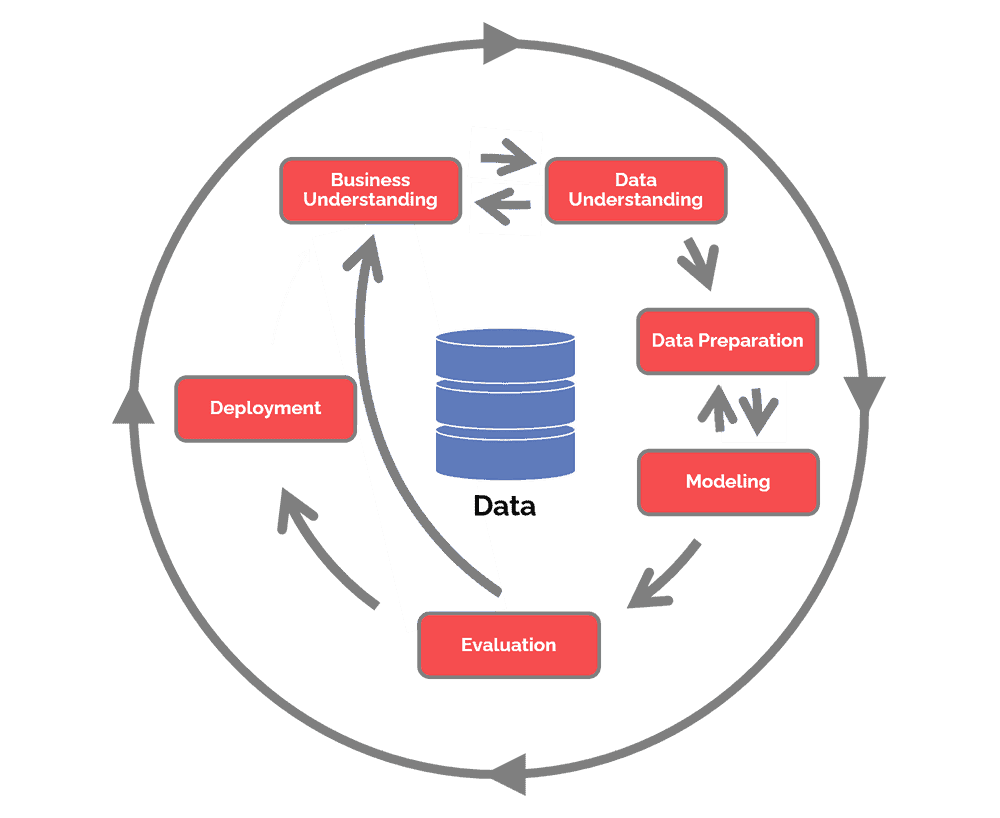

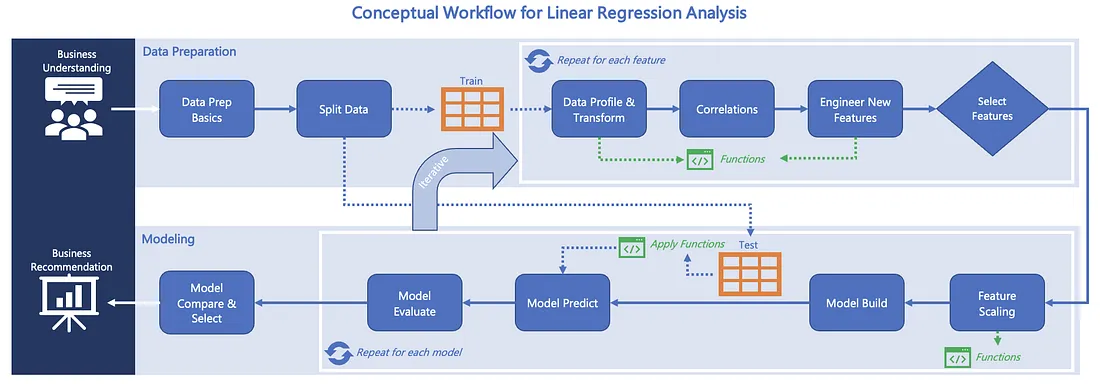

Las ideas simples inherentes en el flujo del proceso incluyen:

*   Divide tus datos antes de hacer demasiado perfilado y análisis.
*   Itera a través de un conjunto común de tareas de preparación de datos para cada característica.
*   Itera a través de una variedad de modelos que contienen diferentes características.
*   Utiliza funciones para la consistencia en las transformaciones de datos y la eficiencia del código en todo el proyecto.

Ahora, comencemos y repasemos un proyecto paso a paso.

### Flujo de Trabajo de Preparación de Datos
Usaremos un conjunto de datos de ventas de viviendas del condado de King, WA, que es popular en Kaggle y con los bootcamps de ciencia de datos. Los datos contienen 21 columnas en más de 20K transacciones de ventas de viviendas completadas en la zona metropolitana de Seattle durante 12 meses entre 2014-2015. El modelo de regresión lineal múltiple utilizará Mínimos Cuadrados Ordinarios (OLS) y predecirá una variable continua 'precio de venta de viviendas'.

Puede encontrar el dataset acá: https://drive.google.com/file/d/1FJ-0ItmRC8vyZhOcFbx7hZmqn5BkC3fL/view?usp=drive_link

#### Paso 1 — Básicos de la Preparación de Datos

Para comenzar a comprender nuestros datos, este proceso incluye tareas básicas como:

- Cargar datos.
- Combinar e integrar datos.
- Convertir tipos de datos.
- Solucionar problemas de calidad de datos.
- Eliminar duplicados.
- Pasos para hacer que los datos estén limpios, formateados y utilizables.

Agrupo todas mis importaciones de bibliotecas juntas en un solo lugar para un fácil acceso.




In [ ]:
%pip install haversine

In [ ]:
# import all libraries required to load, transform, analyze and plot
import numpy as np
import pandas as pd
from pandas.plotting import table
import matplotlib.pyplot as plt
import matplotlib.colors as pltcol
import matplotlib.ticker as ticker
import seaborn as sns
%matplotlib inline
import math

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.tools.eval_measures as ev
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score
from scipy.special import boxcox, inv_boxcox

import scipy.stats as stats
from haversine import haversine #to calculate mileage

# set display option to remove scientific notation and
# remove restrictions on dataframe rows/columns display
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', None)


In [ ]:
ruta_archivo = "/content/drive/MyDrive/notebooks maestria ECI/kc_house_data.csv"

# load Kings County data set (primary driver dataframe)
kc = pd.read_csv(ruta_archivo)
kc.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,"221,900.00",3,1.00,1180,5650,1.00,NaN,0.00,3,7,1180,0.0,1955,0.00,98178,47.51,-122.26,1340,5650
1,6414100192,12/9/2014,"538,000.00",3,2.25,2570,7242,2.00,0.00,0.00,3,7,2170,400.0,1951,"1,991.00",98125,47.72,-122.32,1690,7639
2,5631500400,2/25/2015,"180,000.00",2,1.00,770,10000,1.00,0.00,0.00,3,6,770,0.0,1933,NaN,98028,47.74,-122.23,2720,8062
3,2487200875,12/9/2014,"604,000.00",4,3.00,1960,5000,1.00,0.00,0.00,5,7,1050,910.0,1965,0.00,98136,47.52,-122.39,1360,5000
4,1954400510,2/18/2015,"510,000.00",3,2.00,1680,8080,1.00,0.00,0.00,3,8,1680,0.0,1987,0.00,98074,47.62,-122.05,1800,7503


### Diccionario de Datos del Conjunto de Datos del Condado de Kings

**id**  
identificador único para una casa

**dateDate**  
fecha en que se vendió la casa

**pricePrice**  
es el objetivo de predicción

**bedroomsNumber**  
número de dormitorios por casa

**bathroomsNumber**  
número de baños por dormitorio

**sqft_livingsquare**  
metraje cuadrado de la vivienda

**sqft_lotsquare**  
metraje cuadrado del terreno

**floorsTotal**  
pisos (niveles) en la casa

**waterfront**  
Casa que tiene vista al agua

**view**  
Un índice del 0 al 4 sobre qué tan buena es la vista de la propiedad

**condition**  
Qué tan buena es la condición (en general)

**grade**  
calificación general dada a la unidad de vivienda, basada en el sistema de calificación del Condado de Kings

**sqft_above**  
metraje cuadrado de la casa sin contar el sótano

**sqft_basement**  
metraje cuadrado del sótano

**yr_built**  
Año de construcción

**yr_renovated**  
Año en que la casa fue renovada

**zipcode**  
código postal

**lat**  
Coordenada de latitud

**long**  
Coordenada de longitud

**sqft_living15**  
El metraje cuadrado del espacio interior habitable de la vivienda de los 15 vecinos más cercanos

**sqft_lot15**  
El metraje cuadrado de los terrenos de los 15 vecinos más cercanos

> Se obtuvo contexto adicional de la oficina del tasador del Condado de King para entender los métodos de puntuación de condición y calificación.

### Condición: Relativa a la Edad y Calificación

**1 = Mala**  
Necesita muchas reparaciones. Muestra un serio deterioro.

**2 = Regular**  
Necesita algunas reparaciones de inmediato. Muchos trabajos de mantenimiento pendientes.

**3 = Promedio**  
Dependiendo de la antigüedad de la mejora; cantidad normal de mantenimiento para la edad de la vivienda.

**4 = Buena**  
Condición por encima de la norma para la edad de la vivienda. Indica que se ha prestado atención y cuidado extra en su mantenimiento.

**5 = Muy Buena**  
Excelente mantenimiento y actualización de la vivienda. No es una renovación total.

### Grados de Construcción Residencial

**Grados 1 - 3**  
No cumple con los estándares mínimos de construcción. Normalmente es una cabaña o estructura inferior.

**Grado 4**  
Generalmente construcción antigua de baja calidad. No cumple con el código.

**Grado 5**  
Costos de construcción más bajos y mano de obra de menor calidad. Diseño pequeño y simple.

**Grado 6**  
Calificación más baja que actualmente cumple con los códigos de construcción. Materiales de baja calidad, diseños simples.

**Grado 7**  
Calificación promedio de construcción y diseño. Comúnmente visto en parcelas y subdivisiones antiguas.

**Grado 8**  
Ligeramente por encima del promedio en construcción y diseño. Normalmente mejores materiales tanto en los acabados exteriores como interiores.

**Grado 9**  
Mejor diseño arquitectónico, con diseño exterior e interior adicional y de mejor calidad.

**Grado 10**  
Las viviendas de esta calidad generalmente tienen características de alta calidad. Los acabados son mejores, y se ve más calidad de diseño en los planos y mayor metraje cuadrado.

**Grado 11**  
Diseño personalizado y acabados de mayor calidad, con comodidades adicionales como maderas sólidas, accesorios de baño y opciones más lujosas.

**Grado 12**  
Diseño personalizado y excelentes constructores. Todos los materiales son de la más alta calidad y están presentes todas las comodidades.

**Grado 13**  
Generalmente diseñado y construido a medida. Se acerca al nivel de mansión. Gran cantidad de trabajo de alta calidad en gabinetes, molduras de madera y mármol; entradas grandes.


# Ejercicio en clase

Con el dataset cargado anteriormente, y con la información dada sobre este, realizar los siguientes pasos:

**Paso 1 — Básicos de la Preparación de Datos**

*   Utilizar la instrucción DataFrame.info(), ¿Qué puede concluir del tipo de datos de las variables? ¿Qué otras conclusiones se pueden obtener de esta salida?
*   Haga uso de la instrucción Dataframe.describe() (variables numéricas) y la instrucción Series.value_counts() (variables categóricas). Escriba sus conclusiones sobre lo visto.
*   Identifique anomalías, outliers, duplicados, etc. ¿Qué hacemos con estos registros?

Lidiar con duplicados, fusionar otros datos o cualquier otra tarea general de preparación de datos puede incluirse en este proceso de Básicos de Preparación de Datos. Una vez hecho esto, los datos deben ser consistentes y estar listos para ser divididos para el perfilado de datos, análisis de correlación e ingeniería de características.

**Paso 2 — Perfilado y Transformación de Datos**  

Perfilar y explorar visualmente los datos ayuda a dimensionar características y relaciones potenciales. Si bien cualquier tipo de exploración es válido, enfocaremos iterativamente en estos objetivos para cada predictor $X$ (por ejemplo, dormitorios) y objetivo y (por ejemplo, price_log):

1. Verificar tendencias de variables a lo largo del tiempo.
2. Confirmar relaciones lineales (X-y).
3. Investigar valores atípicos.
4. Evaluar distribuciones de variables, normalidad y sesgo.
5. Convertir clases de variables con codificación one-hot.
6. Gráficos de Variables por Categoría.

*   Identifique y seleccione una variable que pueda servir como variable objetivo $y$, e identifique las variables predictoras.
*   construya histogramas, diagramas de dispersión, boxplots y los N valores acumulativos principales para cada una de las variables predictoras vs la variable independiente. Escriba sus conclusiones sobre lo observado. ¿Qué acciones sobre el dataset se pueden tomar?
*   **Tendencia del Espacio Habitacional Promedio:** Si existen variables basadas en tiempo, analizar tendencias ver dirección o impulso. Por ejemplo, analizar si el espacio habitacional promedio en las casas ha aumentado durante el último siglo. Escriba sus conclusiones.

*   **Análisis de Asociación con Pairplot:** Otra técnica de perfilado de datos es inspeccionar visualmente intersecciones de variables en busca de asociaciones. Construir diagramas de pairplot entre todas las variables incluidas en el dataset.

**Paso 3 — Análisis de Correlación**

El siguiente paso es observar correlaciones con estos objetivos:

1. Validar qué características predictoras (X) se correlacionan con el objetivo (y).
2. Verificar correlaciones entre predictores para multicolinealidad.

*   Calcular el coeficiente de correlación de Pearson entre las variables predictoras y la variable objetivo.

*   **Verificar Multicolinealidad:** Cuando las variables independientes están correlacionadas, indica que los cambios en una variable están asociados con cambios en otra variable. Cuanto más fuerte es la correlación, más difícil es cambiar una variable sin cambiar otra. Revisar las correlaciones entre predictores y crear pares de variables y ordenarlas por la correlación más alta.


**Paso 4 — Crear Nuevas Características**
La primera vez que se pasa por un conjunto de datos al crear un modelo de regresión lineal, es posible que inicialmente no se necesite ninguna nueva característica. Pero después de la primera iteración del modelo, las posibles transformaciones incluyen:

1. Añadir una variable de confusión para reducir el sesgo del modelo.
2. Convertir una característica a per cápita o expresarla como una tasa.
3. Transformar una característica utilizando inversa, logaritmo, raíz cuadrada o box-cox.
4. Añadir una característica polinómica (p.ej. X²) para adaptarse mejor a la curvatura.
5. Añadir un término de interacción para destacar cambios en las relaciones lineales entre dos predictores.

*   Ajuste un modelo de regresión lineal múltiple, con las variables (tanto las predictoras como la objetivo) sin ningún tipo de transformación. ¿Se cumplen los supuestos de la regresión? validar la normalidad en los errores mediante los distintos métodos vistos en clase.

*   **Verificar Normalidad y Crear Funciones Logarítmicas:** Crear series logarítmica y mostrar histogramas dobles para su comparación. Ajuste un modelo de regresión lineal múltiple con la transformación hecha para las variables. Validar la normalidad de los errores.

* Busque, aplique y justifique transformaciones a las variables (escalar, estandarizar, usar una transformación polinómica, etc). Pruebe si estas transformaciones mejoran la eficiencia del modelo. Describa las transformaciones realizadas y las seleccionadas.

**Paso 5 — Seleccionar Características**

El último paso de la preparación de datos es elegir qué características incluir en la siguiente iteración del modelo de regresión. Este proceso de experimentación se basa en su análisis de datos completado y los resultados del modelo anterior.


*   Seleccione las variables (transformadas o no) que seleccionará para su modelo, explique cada una por qué ha sido seleccionada. Recuerde dividir su conjunto de datos en el conjunto de entrenamiento y de prueba.


**Paso 6 — Escalado de Características**

Antes de construir (ajustar) un modelo de regresión lineal, el paso de Escalado de Características abarca cualquier enfoque que puedas necesitar para estandarizar (normalizar), centrar u otras formas de escalar una característica. Funciones comunes de `sklearn` que podrías emplear incluyen `StandardScaler`, `MinMaxScaler` o `RobustScaler`.

**Paso 7 — Construcción del Modelo**

La función `calc_sm_ols` toma los dataframes X y y y ajusta un modelo de regresión de Mínimos Cuadrados Ordinarios (OLS) de `statsmodel`. La función imprime el resumen del modelo, el error cuadrático medio (RMSE) y el Error Absoluto Medio (MAE).

*   Utilice los diferentes métodos para seleccionar el mejor modelo (forward, backward, mixed), pruebe con las distintas interacciones entre variables. Describa cual pueden ser los candidatos a modelos seleccionados, y brinde una interpretación de estos. Valide los supuestos de la regresión. Realice el respectivo análisis de varianza (ANOVA) de estos modelos seleccionados (al menos 3 modelos).

**Paso 8 — Predicción del Modelo**
Ahora, en la recta final, usemos nuestros datos `X_test` y `y_test` que aún no han sido expuestos a nuestro modelo. La función "predict"  toma tanto los datos de prueba como de entrenamiento para aplicar el modelo.

*   Con los modelos candidatos seleccionados, realice la predicción con el conjunto de prueba `X_test` y evalúe su modelo con respecto al vector `y_test`.

**Paso 9 — Selección del Modelo**

*   Brinde una explicación gerencial (con argumentos de más de negocio que técnicos) para argumentar el modelo final seleccionado.








